In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

data = pd.read_csv("../data/processed/analysis_dataset.csv", index_col=0, parse_dates=True)
data.head()

/var/folders/_9/ff9zvgcn55l4__9jy28cxjr40000gn/T/ipykernel_56781/4095160597.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,BAC,GS,JPM,SP500,DGS10,DGS2,VIX,ret_JPM,ret_BAC,ret_GS,ret_SP500,d_DGS10,d_DGS2,d_VIX
2015-01-05,13.573362,149.305878,44.636642,2020.579956,2.04,0.68,19.920000,-0.031537,-0.029481,-0.031720,-0.018447,-0.08,0.02,2.129999
2015-01-06,13.167254,146.285431,43.479256,2002.609985,1.97,0.65,21.120001,-0.026271,-0.030376,-0.020437,-0.008933,-0.07,-0.03,1.200001
2015-01-07,13.229733,148.465546,43.545605,2025.900024,1.96,0.62,19.309999,0.001525,0.004734,0.014793,0.011563,-0.01,-0.03,-1.810001
2015-01-08,13.503080,150.835876,44.518688,2062.139893,2.03,0.62,17.010000,0.022100,0.020451,0.015839,0.017730,0.07,0.00,-2.299999
2015-01-09,13.260975,148.521027,43.744637,2044.810059,1.98,0.59,17.549999,-0.017540,-0.018092,-0.015466,-0.008439,-0.05,-0.03,0.539999


In [5]:
def run_regression(bank_return_col, data):
    y = data[bank_return_col]
    X = data[["d_DGS10", "d_VIX", "ret_SP500"]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    return model

model_jpm = run_regression("ret_JPM", data)
print(model_jpm.summary())

                            OLS Regression Results                            
Dep. Variable:                ret_JPM   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     358.1
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          6.52e-198
Time:                        12:09:52   Log-Likelihood:                 8912.9
No. Observations:                2914   AIC:                        -1.782e+04
Df Residuals:                    2910   BIC:                        -1.779e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.921      0.3

In [6]:
model_bac = run_regression("ret_BAC", data)
model_gs = run_regression("ret_GS", data)
model_sp500 = run_regression("ret_SP500", data)

print(model_bac.summary())

                            OLS Regression Results                            
Dep. Variable:                ret_BAC   R-squared:                       0.535
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     394.9
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.63e-215
Time:                        12:09:52   Log-Likelihood:                 8502.6
No. Observations:                2914   AIC:                        -1.700e+04
Df Residuals:                    2910   BIC:                        -1.697e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.558e-05      0.000     -0.354      0.7

In [7]:
results = pd.DataFrame({
    "JPM": [model_jpm.params["d_DGS10"], model_jpm.pvalues["d_DGS10"]],
    "BAC": [model_bac.params["d_DGS10"], model_bac.pvalues["d_DGS10"]],
    "GS": [model_gs.params["d_DGS10"], model_gs.pvalues["d_DGS10"]],
    "SP500": [model_sp500.params["d_DGS10"], model_sp500.pvalues["d_DGS10"]],
}, index=["beta_DGS10", "p_value"])

results

,JPM,BAC,GS,SP500
beta_DGS10,6.592533e-02,8.046011e-02,3.666595e-02,-2.718224e-15
p_value,6.012542e-24,1.132017e-28,2.361281e-07,9.501242e-49


In [8]:
def run_regression_market(data):
    y = data["ret_SP500"]
    X = data[["d_DGS10", "d_VIX"]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    return model

model_sp500_correct = run_regression_market(data)
print(model_sp500_correct.summary())

                            OLS Regression Results                            
Dep. Variable:              ret_SP500   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     287.9
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          8.28e-115
Time:                        12:13:36   Log-Likelihood:                 10428.
No. Observations:                2914   AIC:                        -2.085e+04
Df Residuals:                    2911   BIC:                        -2.083e+04
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      3.817      0.0

In [9]:
results = pd.DataFrame({
    "JPM": [model_jpm.params["d_DGS10"], model_jpm.pvalues["d_DGS10"]],
    "BAC": [model_bac.params["d_DGS10"], model_bac.pvalues["d_DGS10"]],
    "GS": [model_gs.params["d_DGS10"], model_gs.pvalues["d_DGS10"]],
    "SP500": [model_sp500_correct.params["d_DGS10"], model_sp500_correct.pvalues["d_DGS10"]],
}, index=["beta_DGS10", "p_value"])

results

,JPM,BAC,GS,SP500
beta_DGS10,6.592533e-02,8.046011e-02,3.666595e-02,0.005411
p_value,6.012542e-24,1.132017e-28,2.361281e-07,0.280344


In [10]:
from scipy import stats

def compare_betas(model1, model2, var="d_DGS10"):
    b1 = model1.params[var]
    b2 = model2.params[var]
    se1 = model1.bse[var]
    se2 = model2.bse[var]
    diff = b1 - b2
    se_diff = np.sqrt(se1**2 + se2**2)
    z = diff / se_diff
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return diff, z, p

print("JPM vs BAC:", compare_betas(model_jpm, model_bac))
print("JPM vs GS:", compare_betas(model_jpm, model_gs))
print("BAC vs GS:", compare_betas(model_bac, model_gs))

JPM vs BAC: (-0.014534784466133543, -1.490205383070267, 0.1361702414164332)
JPM vs GS: (0.029259373140946815, 3.03398836362908, 0.0024134373873152537)
BAC vs GS: (0.04379415760708036, 4.319674972930383, 1.5625917323403016e-05)


In [11]:
import matplotlib.pyplot as plt

def rolling_beta(y_col, data, window=252):
    betas = []
    dates = []
    for i in range(window, len(data)):
        window_data = data.iloc[i-window:i]
        y = window_data[y_col]
        X = sm.add_constant(window_data[["d_DGS10", "d_VIX", "ret_SP500"]])
        model = sm.OLS(y, X).fit()
        betas.append(model.params["d_DGS10"])
        dates.append(data.index[i])
    return pd.Series(betas, index=dates)

rolling_jpm = rolling_beta("ret_JPM", data)
rolling_bac = rolling_beta("ret_BAC", data)
rolling_gs = rolling_beta("ret_GS", data)

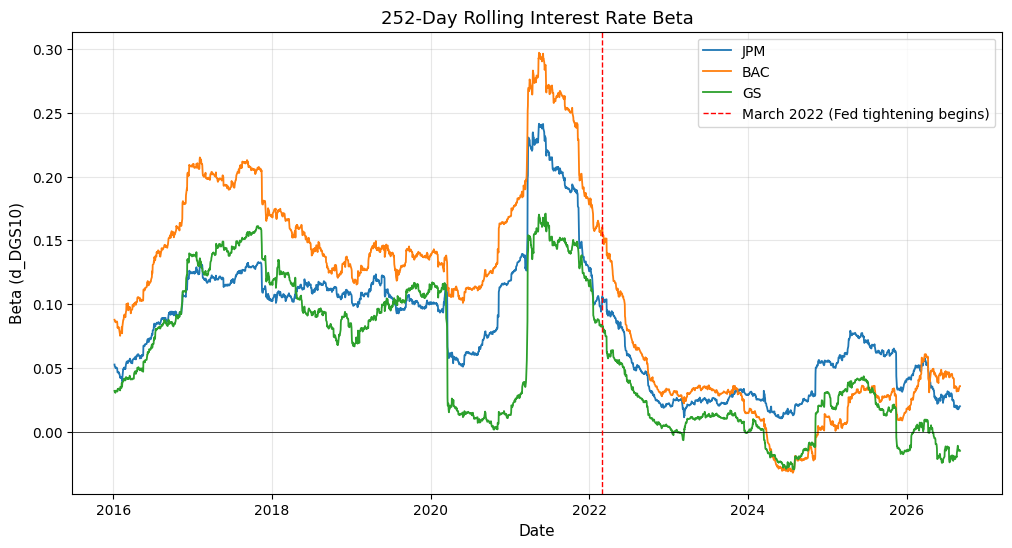

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(rolling_jpm, label="JPM", linewidth=1.3)
plt.plot(rolling_bac, label="BAC", linewidth=1.3)
plt.plot(rolling_gs, label="GS", linewidth=1.3)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(pd.Timestamp("2022-03-01"), color="red", linestyle="--", linewidth=1, label="March 2022 (Fed tightening begins)")
plt.title("252-Day Rolling Interest Rate Beta", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Beta (d_DGS10)", fontsize=11)
plt.grid(alpha=0.3)
plt.legend()
plt.savefig("../figures/rolling_beta.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
def run_regression_2y(bank_return_col, data):
    y = data[bank_return_col]
    X = data[["d_DGS2", "d_VIX", "ret_SP500"]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    return model

model_jpm_2y = run_regression_2y("ret_JPM", data)
model_bac_2y = run_regression_2y("ret_BAC", data)
model_gs_2y = run_regression_2y("ret_GS", data)

def run_regression_market_2y(data):
    y = data["ret_SP500"]
    X = data[["d_DGS2", "d_VIX"]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    return model

model_sp500_2y = run_regression_market_2y(data)

results_2y = pd.DataFrame({
    "JPM": [model_jpm_2y.params["d_DGS2"], model_jpm_2y.pvalues["d_DGS2"]],
    "BAC": [model_bac_2y.params["d_DGS2"], model_bac_2y.pvalues["d_DGS2"]],
    "GS": [model_gs_2y.params["d_DGS2"], model_gs_2y.pvalues["d_DGS2"]],
    "SP500": [model_sp500_2y.params["d_DGS2"], model_sp500_2y.pvalues["d_DGS2"]],
}, index=["beta_DGS2", "p_value"])

results_2y

,JPM,BAC,GS,SP500
beta_DGS2,4.835834e-02,5.713865e-02,0.027236,-0.000182
p_value,1.687547e-20,3.665533e-20,0.000004,0.965366


In [14]:
results.to_csv("../data/processed/regression_results_10y.csv")
results_2y.to_csv("../data/processed/regression_results_2y.csv")